In [1]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path
import numpy as np
import pandas as pd
from decimal import Decimal

from scipy.optimize import curve_fit

import astropy.units as u
from astropy.coordinates import Angle, SkyCoord, EarthLocation, AltAz
from astropy.time import Time
from astropy.table import Table
from gammapy.data import Observation, observatory_locations, EventList
from gammapy.datasets import MapDataset, MapDatasetEventSampler, FluxPointsDataset
from gammapy.estimators import ASmoothMapEstimator, TSMapEstimator, ExcessMapEstimator
from gammapy.estimators import FluxPointsEstimator
from gammapy.estimators.utils import resample_energy_edges
from gammapy.irf import load_irf_dict_from_file
from gammapy.makers import MapDatasetMaker, RingBackgroundMaker, SafeMaskMaker
from gammapy.datasets import MapDataset, MapDatasetOnOff
from gammapy.makers import MapDatasetMaker, WobbleRegionsFinder
from gammapy.maps import MapAxis, RegionNDMap, WcsGeom, Map, TimeMapAxis
from gammapy.modeling import Fit
from gammapy.modeling.models import (
    ConstantSpectralModel,
    FoVBackgroundModel,
    LightCurveTemplateTemporalModel,
    Models,
    PointSpatialModel,
    PowerLawSpectralModel,
    LogParabolaSpectralModel,
    SkyModel,
)
from regions import PointSkyRegion, CircleSkyRegion

from IPython.display import display
from gammapy.data import DataStore
from gammapy.datasets import (
    Datasets,
    FluxPointsDataset,
    SpectrumDataset,
    SpectrumDatasetOnOff,
)
from gammapy.estimators import FluxPointsEstimator
from gammapy.makers import (
    ReflectedRegionsBackgroundMaker,
    SafeMaskMaker,
    SpectrumDatasetMaker,
    FoVBackgroundMaker
)
from gammapy.makers.utils import make_theta_squared_table

from gammapy.maps import MapAxis, RegionGeom, WcsGeom
from gammapy.modeling import Fit
from gammapy.modeling.models import (
    ExpCutoffPowerLawSpectralModel,
    SkyModel,
    create_crab_spectral_model,
    PiecewiseNormSpectralModel,
    PowerLawNormSpectralModel,
    LogParabolaSpectralModel,
)

from gammapy.visualization import (
        plot_spectrum_datasets_off_regions,
        plot_theta_squared_table
        )
from gammapy.maps.utils import edges_from_lo_hi

from gammapy.stats import WStatCountsStatistic, CashCountsStatistic

import warnings

In [2]:
def gaus(x, a, sigma):
    return a * np.exp(-(x - 0)**2 / (2 * sigma**2))

def gaus2(x, a1, x1, sigma1, a2, x2, sigma2):
    return gaus(x, a1, sigma1) + gaus(x, a2, sigma2)

def gaus3(x, a1, sigma1, a2, sigma2, a3, sigma3):
    return gaus(x, a1, sigma1) + gaus(x, a2, sigma2)+ gaus(x, a3, sigma3)

def gaus_cost(x, a, sigma, C):
    return a * np.exp(-(x - 0)**2 / (2 * sigma**2)) + C

def king(r, a, sigma, gamma):
    return a * 1 / (2 * np.pi * sigma**2) * (1 - 1/gamma) * (1 + r**2 / (2 * gamma * sigma**2))**(-gamma)

In [3]:
import yaml

def read_yaml(file_path):
    with open(file_path, "r") as f:
        return yaml.safe_load(f)

In [4]:
def make_theta_squared_table_modified(
    observations, 
    theta_squared_axis, 
    position, 
    position_off=None, 
    angle_pos_off = Angle(180 * u.deg),
    energy_edges=None
):
    """Make theta squared distribution in the same FoV for a list of `~gammapy.data.Observation` objects.

    The ON theta2 profile is computed from a given distribution, on_position.
    By default, the OFF theta2 profile is extracted from a mirror position
    radially symmetric in the FOV to pos_on.

    The ON and OFF regions are assumed to be of the same size, so the normalisation
    factor between both region alpha = 1.

    Parameters
    ----------
    observations: `~gammapy.data.Observations`
        List of observations.
    theta_squared_axis : `~gammapy.maps.MapAxis`
        Axis of edges of the theta2 bin used to compute the distribution.
    position : `~astropy.coordinates.SkyCoord`
        Position from which the on theta^2 distribution is computed.
    position_off : `astropy.coordinates.SkyCoord`
        Position from which the OFF theta^2 distribution is computed.
        Default is reflected position w.r.t. to the pointing position.
    angle_pos_off : `Angle`
        Position angle for OFF region; by default is 180°.
    energy_edges : list of `~astropy.units.Quantity`, optional
        Edges of the energy bin where the theta squared distribution
        is evaluated. For now, only one interval is accepted.
        Default is None.

    Returns
    -------
    table : `~astropy.table.Table`
        Table containing the on counts, the off counts, acceptance, off acceptance and alpha
        for each theta squared bin.
    """
    if not theta_squared_axis.edges.unit.is_equivalent("deg2"):
        raise ValueError("The theta2 axis should be equivalent to deg2")

    table = Table()

    table["theta2_min"] = theta_squared_axis.edges[:-1]
    table["theta2_max"] = theta_squared_axis.edges[1:]
    table["counts"] = 0
    table["counts_off"] = 0
    table["acceptance"] = 0.0
    table["acceptance_off"] = 0.0

    alpha_tot = np.zeros(len(table))
    livetime_tot = 0

    create_off = position_off is None

    if energy_edges is not None:
        if len(energy_edges) == 2:
            table.meta["Energy_filter"] = energy_edges
        else:
            raise ValueError(
                f"Only  supports one energy interval but {len(energy_edges) - 1} passed."
            )

    for observation in observations:
        events = observation.events
        if energy_edges is not None:
            events = events.select_energy(energy_range=energy_edges)

        event_position = events.radec
        pointing = observation.get_pointing_icrs(observation.tmid)

        separation = position.separation(event_position)
        counts, _ = np.histogram(separation**2, theta_squared_axis.edges)
        table["counts"] += counts

        if create_off:
            # Estimate the position of the mirror position
            pos_angle = pointing.position_angle(position)
            sep_angle = pointing.separation(position)
            position_off = pointing.directional_offset_by(
                pos_angle + angle_pos_off, sep_angle
            )

        # Angular distance of the events from the mirror position
        separation_off = position_off.separation(event_position)

        # Extract the ON and OFF theta2 distribution from the two positions.
        counts_off, _ = np.histogram(separation_off**2, theta_squared_axis.edges)
        table["counts_off"] += counts_off

        # Normalisation between ON and OFF is one
        acceptance = np.ones(theta_squared_axis.nbin)
        acceptance_off = np.ones(theta_squared_axis.nbin)

        table["acceptance"] += acceptance
        table["acceptance_off"] += acceptance_off
        alpha = acceptance / acceptance_off
        alpha_tot += alpha * observation.observation_live_time_duration.to_value("s")
        livetime_tot += observation.observation_live_time_duration.to_value("s")

    alpha_tot /= livetime_tot
    table["alpha"] = alpha_tot

    stat = WStatCountsStatistic(table["counts"], table["counts_off"], table["alpha"])
    table["excess"] = stat.n_sig
    table["sqrt_ts"] = stat.sqrt_ts
    table["excess_errn"] = stat.compute_errn()
    table["excess_errp"] = stat.compute_errp()

    table.meta["ON_RA"] = position.icrs.ra
    table.meta["ON_DEC"] = position.icrs.dec
    return table


def make_theta_squared_table_reflected(
    observations, 
    theta_squared_axis, 
    position, 
    position_off=None,
    off_regions_number=1,
    energy_edges=None
):
    """Make theta squared distribution in the same FoV for a list of `~gammapy.data.Observation` objects.

    The ON theta2 profile is computed from a given distribution, on_position.
    By default, the OFF theta2 profile is extracted from a mirror position
    radially symmetric in the FOV to pos_on.

    The ON and OFF regions are assumed to be of the same size, so the normalisation
    factor between both region alpha = 1.

    Parameters
    ----------
    observations: `~gammapy.data.Observations`
        List of observations.
    theta_squared_axis : `~gammapy.maps.MapAxis`
        Axis of edges of the theta2 bin used to compute the distribution.
    position : `~astropy.coordinates.SkyCoord`
        Position from which the on theta^2 distribution is computed.
    position_off : `astropy.coordinates.SkyCoord`
        Position from which the OFF theta^2 distribution is computed.
        Default is reflected position w.r.t. to the pointing position.
    off_regions_number : `~int`
        Number of OFF regions; by default is 1.
    energy_edges : list of `~astropy.units.Quantity`, optional
        Edges of the energy bin where the theta squared distribution
        is evaluated. For now, only one interval is accepted.
        Default is None.

    Returns
    -------
    table : `~astropy.table.Table`
        Table containing the on counts, the off counts, acceptance, off acceptance and alpha
        for each theta squared bin.
    """
    if not theta_squared_axis.edges.unit.is_equivalent("deg2"):
        raise ValueError("The theta2 axis should be equivalent to deg2")

    table = Table()

    table["theta2_min"] = theta_squared_axis.edges[:-1]
    table["theta2_max"] = theta_squared_axis.edges[1:]
    table["counts"] = 0
    table["counts_off"] = 0.0
    table["acceptance"] = 0.0
    table["acceptance_off"] = 0.0

    alpha_tot = np.zeros(len(table))
    livetime_tot = 0

    create_off = position_off is None

    if energy_edges is not None:
        if len(energy_edges) == 2:
            table.meta["Energy_filter"] = energy_edges
        else:
            raise ValueError(
                f"Only  supports one energy interval but {len(energy_edges) - 1} passed."
            )

    for observation in observations:
        events = observation.events
        if energy_edges is not None:
            events = events.select_energy(energy_range=energy_edges)

        event_position = events.radec
        pointing = observation.get_pointing_icrs(observation.tmid)

        separation = position.separation(event_position)
        counts, _ = np.histogram(separation**2, theta_squared_axis.edges)
        table["counts"] += counts

        pos_angle = pointing.position_angle(position)
        sep_angle = pointing.separation(position)

        if off_regions_number > 1 and create_off is False:
            raise ValueError("If `off_regions_number` is larger than 1, `position_off` has to be set to None.")

        if off_regions_number > 1:
            off_region_angles = Angle(360 * u.deg) / (off_regions_number + 1)
            off_region_angle = pos_angle + off_region_angles * np.arange(1, off_regions_number + 1)
            off_regions = pointing.directional_offset_by(off_region_angle, sep_angle)

            counts_off = np.zeros_like(counts)
            for off_region in off_regions:
                # Angular distance of the events from the mirror position
                separation_off = off_region.separation(event_position)
     
                # Extract the ON and OFF theta2 distribution from the two positions.
                counts_off_regions, _ = np.histogram(separation_off**2, theta_squared_axis.edges)
                counts_off += counts_off_regions

        if off_regions_number == 1: 
            if create_off:
                # Estimate the position of the mirror position
                position_off = pointing.directional_offset_by(
                    pos_angle + Angle(np.pi, "rad"), sep_angle
                )
    
            separation_off = position_off.separation(event_position)
            counts_off, _ = np.histogram(separation_off**2, theta_squared_axis.edges)

        table["counts_off"] += np.array(counts_off)

        # Normalisation between ON and OFF is one
        acceptance = np.ones(theta_squared_axis.nbin)
        acceptance_off = np.ones(theta_squared_axis.nbin) * off_regions_number

        table["acceptance"] += acceptance
        table["acceptance_off"] += acceptance_off
        alpha = acceptance / acceptance_off
        alpha_tot += alpha * observation.observation_live_time_duration.to_value("s")
        livetime_tot += observation.observation_live_time_duration.to_value("s")

    alpha_tot /= livetime_tot
    table["alpha"] = alpha_tot

    stat = WStatCountsStatistic(table["counts"], table["counts_off"], table["alpha"])
    table["excess"] = stat.n_sig
    table["sqrt_ts"] = stat.sqrt_ts
    table["excess_errn"] = stat.compute_errn()
    table["excess_errp"] = stat.compute_errp()

    table.meta["ON_RA"] = position.icrs.ra
    table.meta["ON_DEC"] = position.icrs.dec
    return table

In [5]:
parfile = "./ASTRI_quicklook_analysis_parfile.yaml"
global_parameters = read_yaml(parfile)

In [6]:
output_dir = global_parameters['OUTPUT_RESULTS']['output_dir']
output_dir_notebook = global_parameters['OUTPUT_RESULTS']['theta2_output_dir']
Path(output_dir).mkdir(parents=True, exist_ok=True)
Path(output_dir).joinpath(output_dir_notebook).mkdir(parents=True, exist_ok=True)

## Load the ASTRI data

In [7]:
import glob, os, pathlib, itertools

target_name = global_parameters["TARGET"]["target_name"]

input_filenames = []
for folder in global_parameters['INPUT_DATA']['input_EVT3']:
    input_filenames.append(glob.glob(os.path.join(folder, f'*{target_name}*_0201_*.fits.gz')))
input_filenames = tuple(itertools.chain.from_iterable(input_filenames))

irf_filenames = []
for folder in global_parameters['INPUT_DATA']['input_IRF3']:
    irf_filenames.append(glob.glob(os.path.join(folder, f'*{target_name}*_0502_*.fits.gz')))
irf_filenames = tuple(itertools.chain.from_iterable(irf_filenames))

print(f"The number of runs is {len(input_filenames)}; the number of IRF is {len(irf_filenames)}.")
if len(input_filenames) != len(irf_filenames):
    warnings.warn("The number of runs is not compatible with the available IRFs! PLEASE CHECK!")
else:
    print("Run and abailable IRFs are compatible!")

datastore = DataStore.from_events_files(np.sort(input_filenames), irfs_paths=np.sort(irf_filenames))
datastore.hdu_table.write("hdu-index.fits.gz", overwrite=True)
datastore.obs_table.write("obs-index.fits.gz", overwrite=True)

The number of runs is 49; the number of IRF is 49.
Run and abailable IRFs are compatible!


In [8]:
telescope_name = global_parameters["DATA_ORIGIN"]["telescope"]
target_name = global_parameters["TARGET"]["target_name"]
obs_date = datastore.obs_table[0]["EVENTS_FILENAME"].split("/")[-1][0:8]

In [9]:
import json

with open(f'{output_dir}/{output_dir_notebook}/theta2_output_dir_parfile_summary_{obs_date}_{telescope_name}_{target_name}.txt', 'w') as file:
    file.write(json.dumps(global_parameters))

## Create AZ/ZD columns in the datastore for each run

In [10]:
ev_header = Table.read(datastore.obs_table["EVENTS_FILENAME"][0], hdu=1)
meta = ev_header.meta
loc = EarthLocation(
            lat=global_parameters['DATA_ORIGIN']['latitude'],
            lon=global_parameters['DATA_ORIGIN']['longitude'],
            # height = (row["TELZ"] + OBSLEV)*u.m
        )

mjdtime = ( ((datastore.obs_table["TSTART"] + datastore.obs_table["TSTOP"])/2).to("d") 
           + (datastore.obs_table["MJDREFI"] + datastore.obs_table["MJDREFF"]) * u.d )
observing_time = Time(mjdtime, format="mjd", scale="tt")  

altazframe = AltAz(location=loc, obstime=observing_time)
datastore.obs_table["DATE-OBS"] = observing_time.isot 
coord = SkyCoord(datastore.obs_table["RA_PNT"], datastore.obs_table["DEC_PNT"], unit="deg", frame="icrs")
coord_altaz = coord.transform_to(altazframe)

datastore.obs_table["AZ_PNT"] = coord_altaz.az.deg * u.deg
datastore.obs_table["ZD_PNT"] = coord_altaz.zen.deg * u.deg

## Select runs according to selection criteria

In [11]:
target_position = SkyCoord(ra=global_parameters['TARGET']['coord1'], 
                           dec=global_parameters['TARGET']['coord2'], 
                           unit="deg", 
                           frame=global_parameters['TARGET']['frame'])

selection_offset = dict(type='sky_circle',
                lon=target_position.ra.deg,
                lat=target_position.dec.deg,
                frame="icrs",
                radius=Angle(global_parameters['RUN_SELECTION']['offset_max'], 'deg')
                )

value_range_zen = Angle([global_parameters['RUN_SELECTION']['zenith_min'], 
                         global_parameters['RUN_SELECTION']['zenith_max']], 'deg')
selection_zen = dict(type='par_box', variable='ZD_PNT', value_range=value_range_zen)

value_range_az = Angle([global_parameters['RUN_SELECTION']['azimuth_min'], 
                     global_parameters['RUN_SELECTION']['azimuth_max']], 'deg')
selection_az = dict(type='par_box', variable='AZ_PNT', value_range=value_range_az)

value_range_time = np.array([global_parameters['RUN_SELECTION']['tstart'],
                             global_parameters['RUN_SELECTION']['tstop']], float) * u.s
selection_time = dict(type='par_box', variable='TSTART', value_range=value_range_time)

select_obs = datastore.obs_table.select_observations([selection_offset, selection_zen, selection_az, selection_time])
selected_obsid = select_obs["OBS_ID"]

In [12]:
exp_tot = (np.sum(select_obs['LIVETIME']) * u.s).to('hr')
print(f"The mean exposure of the runs is {np.mean(select_obs['LIVETIME']) * u.s} \n")
print(f"The total exposure time is {(np.sum(select_obs['LIVETIME']) * u.s).to('hr')} \n")
print(f"The total runs are {len(select_obs['OBS_ID'])}. These are the selected ObsID: \n {select_obs['OBS_ID']} \n")

The mean exposure of the runs is 1933.6122448979593 s 

The total exposure time is 26.31861111111111 h 

The total runs are 49. These are the selected ObsID: 
   OBS_ID  
----------
 433001063
 486001135
 487001136
 488001137
 507001172
 553001221
 554001222
 612001388
 619001403
 620001404
       ...
 985001976
 998001994
 999001995
1007002010
1008002011
1015002025
1041002054
1042002055
1056002075
1064002087
Length = 49 rows 



In [13]:
file_path = Path(f"{output_dir}/{output_dir_notebook}/theta2_summary_table_{obs_date}_{telescope_name}_{target_name}.txt")
with file_path.open('w') as file:
    file.write(f"The mean exposure of the runs is {np.mean(select_obs['LIVETIME']) * u.s} \n\n" +
               f"The total exposure time is {(np.sum(select_obs['LIVETIME']) * u.s).to('hr')} \n\n" +
               f"The total runs are {len(select_obs['OBS_ID'])}. These are the selected ObsID: \n {select_obs['OBS_ID']}"
              )

## Load the observations

In [14]:
observations = datastore.get_observations(obs_id=selected_obsid)

In [15]:
irf_psf = observations[0].psf

## Make a theta2 plot with Gammapy

In [16]:
min_rad, max_rad, nbin = (global_parameters['THETA2_PARAM']['min_rad'], 
                          global_parameters['THETA2_PARAM']['max_rad'], 
                          global_parameters['THETA2_PARAM']['nbin_rad'])
rad_axis = MapAxis.from_bounds(min_rad, max_rad, nbin=nbin, unit="deg2", interp="lin")

e_min, e_max = (global_parameters['DATASET_SETTINGS']['energy_reco_min'] * u.TeV, 
                global_parameters['DATASET_SETTINGS']['energy_reco_max'] * u.TeV) 

energy_axis = MapAxis.from_energy_bounds(
                    e_min, e_max, 
                    nbin=global_parameters['DATASET_SETTINGS']['nbin_reco'], 
                    per_decade=False, unit="TeV", name="energy") 

energy_axis = energy_axis.downsample(2) 
erange = energy_axis.edges

#### - As a function of energy bins:

Default OFF position(s)
Default OFF position(s)
Default OFF position(s)
Default OFF position(s)
Default OFF position(s)
Default OFF position(s)
Default OFF position(s)
Default OFF position(s)


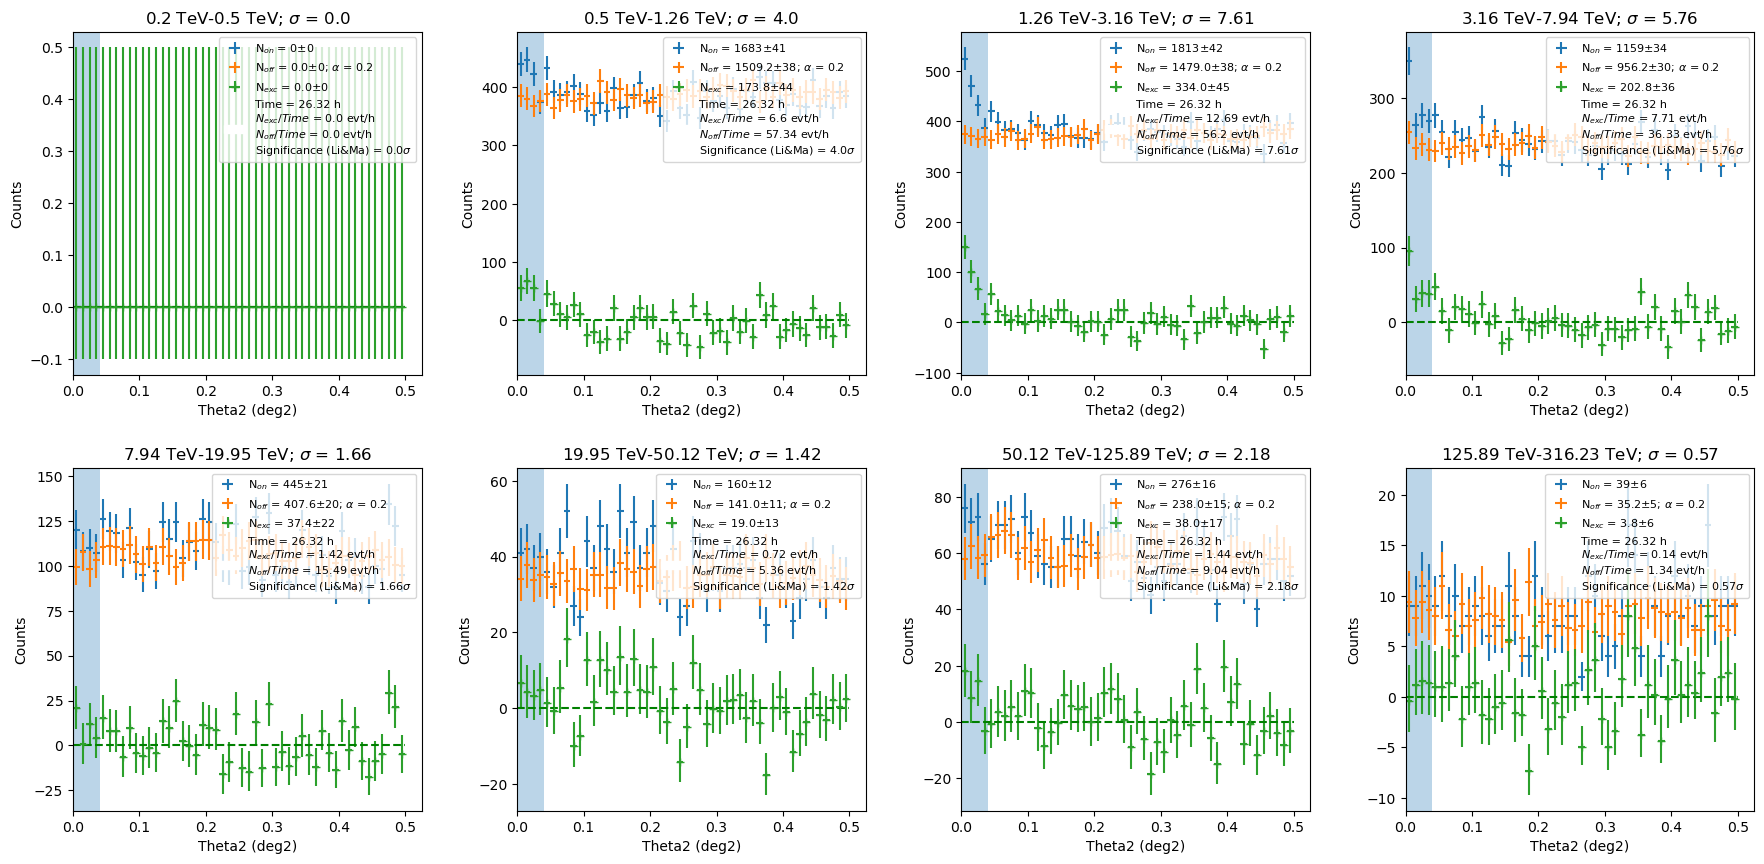

In [17]:
off_regions_number = global_parameters['THETA2_PARAM']['off_regions_number']

n, sigma, c = 50, 0.02, 0
col = 4
row = int((len(erange) - 1) / col)
ratio = int(col / row)

fig, axs = plt.subplots(row, col, figsize=(18, 18/ratio))

j, jj = 0, 0
best, best_err = [], []
for i in np.arange(len(erange)-1):
    energy = np.sqrt(erange[1:] * erange[:-1])[i]

    if global_parameters['THETA2_PARAM']['usr_defined_off_position'] == False:
        print("Default OFF position(s)")
        theta2_dist = make_theta_squared_table_reflected(observations=observations, 
                                               theta_squared_axis=rad_axis, 
                                               position=target_position, 
                                               position_off=None,
                                               off_regions_number = off_regions_number,
                                               energy_edges=[erange[i], erange[i+1]])

    if global_parameters['THETA2_PARAM']['usr_defined_off_position'] == True:
        print("User defined OFF position")
        new_angle = Angle(global_parameters['THETA2_PARAM']['off_position_angle'])

        theta2_dist = make_theta_squared_table_modified(observations=observations, 
                                                       theta_squared_axis=rad_axis, 
                                                       position=target_position, 
                                                       angle_pos_off = new_angle,
                                                       energy_edges=[erange[i], erange[i+1]])

    
    theta2_dist_mod = theta2_dist[theta2_dist["theta2_max"] <= global_parameters['THETA2_PARAM']['on_radius']]

    alpha = np.sum(theta2_dist_mod["alpha"]) / len(theta2_dist_mod["alpha"])
    n_on = theta2_dist_mod["counts"].sum()
    n_off = theta2_dist_mod["counts_off"].sum() 

    stat_ws = WStatCountsStatistic(n_on=n_on, n_off=n_off, alpha=alpha)
    excs = stat_ws.n_sig
    excess_errn = stat_ws.compute_errn()
    excess_errp = stat_ws.compute_errp()


    theta2_edges = edges_from_lo_hi(
    theta2_dist["theta2_min"].quantity, theta2_dist["theta2_max"].quantity
            )
    theta2_axis = MapAxis.from_edges(theta2_edges, interp="lin", name="theta_squared")

    x = theta2_axis.center.value
    x_edges = theta2_axis.edges.value
    xerr = (x - x_edges[:-1], x_edges[1:] - x)

    axs[j,jj].errorbar(
        x,
        theta2_dist["counts"],
        xerr=xerr,
        yerr=np.sqrt(theta2_dist["counts"]),
        linestyle="None",
        label=r"N$_{on}$ = "+ f"{n_on}" + r"$\pm$" + f"{int(n_on**0.5)}",
    )

    axs[j,jj].errorbar(
        x,
        theta2_dist["counts_off"] * theta2_dist["alpha"],
        xerr=xerr,
        yerr=np.sqrt(theta2_dist["counts_off"] * theta2_dist["alpha"]),
        linestyle="None",
        label=r"N$_{off}$ = "+ f"{np.round(n_off * alpha,2)}" + r"$\pm$" + f"{int((n_off * alpha)**0.5)}; " + r"$\alpha$ = " + f"{np.round(alpha,2)}",
    )

    
    axs[j,jj].errorbar(
        x,
        theta2_dist["excess"],
        xerr=xerr,
        yerr=(theta2_dist["excess_errn"], theta2_dist["excess_errp"]),
        fmt="+",
        linestyle="None",
        label=r"N$_{exc}$ = "+ f"{np.round(excs,2)}" + r"$\pm$" + f"{int(excess_errn)}",
    )

    axs[j,jj].set_ylabel("Counts")
    axs[j,jj].set_xlabel("Theta2 (deg2)")
    axs[j,jj].legend()

    if global_parameters['THETA2_PARAM']['gauss_fit_excess']:
        popt, pcov = curve_fit(gaus_cost, x, theta2_dist["excess"],
                                sigma=theta2_dist["excess_errn"],
                                p0=[n, sigma, c],
                                maxfev = 100000000)
    
        best.append(popt)
        best_err.append(pcov)
        
        sig_irf = irf_psf.containment_radius(fraction=0.68, energy_true=[energy]*u.TeV, offset=[0.5]*u.deg) * 0.6624305
        axs[j,jj].plot(x, gaus_cost(x, *popt), label=f"{np.round(popt[1]**0.5,3)} deg, {np.round(sig_irf[0],3)}", color="green")

    y_min, y_max = axs[j,jj].get_ylim()
    axs[j,jj].fill_between(x_edges[(x_edges <= global_parameters['THETA2_PARAM']['on_radius'])], y_min, y_max, alpha=0.3)

    axs[j,jj].set_title(f"{np.round(erange[i],2)}-{np.round(erange[i+1],2)}; " + r"$\sigma$ = " + f"{np.round(stat_ws.sqrt_ts,2)}")

    legend = axs[j,jj].legend(fontsize="8", loc ="upper right")
    handles, labels = axs[j,jj].get_legend_handles_labels()
    handles.append(Patch(facecolor='w', edgecolor='w'))
    labels.append(f"Time = {np.round(exp_tot,2)} \n" + 
                  r"$N_{exc}/Time$ = " + f"{np.round((excs) / exp_tot.value,2)} " + r"evt/h" + "\n" +
                  r"$N_{off}/Time$ = " + f"{np.round((n_off * alpha) / exp_tot.value,2)} " + r"evt/h" + "\n" +
                  f"Significance (Li&Ma) = {np.round(stat_ws.sqrt_ts,2)}" + r"$\sigma$"
                 )
    
    legend._legend_box = None
    legend._init_legend_box(handles, labels)
    legend._set_loc(legend._loc)
    legend.set_title(legend.get_title().get_text())

    axs[j,jj].set_ylim(y_min,y_max)
    axs[j,jj].set_xlim(0)

    axs[j,jj].hlines(0, x_edges[0], x_edges[-1], color="green", linestyles="dashed")

    jj += 1
    if jj == 4:
        jj = 0
        j += 1
        
fig.tight_layout(pad=2.0)        
plt.savefig(f"{output_dir}/{output_dir_notebook}/theta2_plot_energy_bins_{obs_date}_{telescope_name}_{target_name}.pdf", bbox_inches='tight')
plt.savefig(f"{output_dir}/{output_dir_notebook}/theta2_plot_energy_bins_{obs_date}_{telescope_name}_{target_name}.png", bbox_inches='tight')

#### - For a given energy range:

Default OFF position(s)


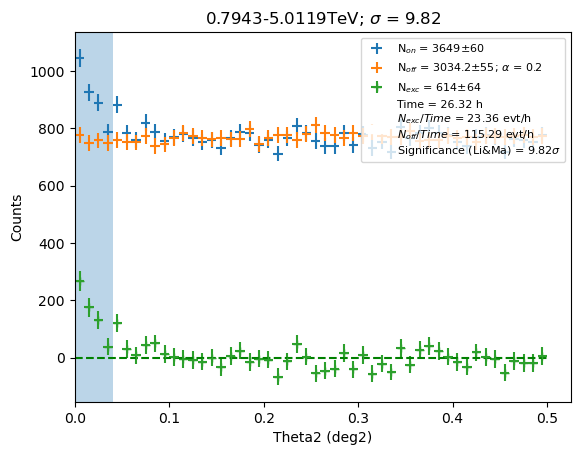

In [18]:
if global_parameters['THETA2_PARAM']['usr_defined_off_position'] == False:
    print("Default OFF position(s)")
    theta2_dist = make_theta_squared_table_reflected(observations=observations, 
                                           theta_squared_axis=rad_axis, 
                                           position=target_position, 
                                           position_off=None,
                                           off_regions_number = off_regions_number,
                                           energy_edges=[global_parameters['THETA2_PARAM']['energy_min'], 
                                                         global_parameters['THETA2_PARAM']['energy_max']] * u.TeV 
                                           )

if global_parameters['THETA2_PARAM']['usr_defined_off_position'] == True:
    print("User defined OFF position")
    new_angle = Angle(global_parameters['THETA2_PARAM']['off_position_angle'])

    theta2_dist = make_theta_squared_table_modified(observations=observations, 
                                           theta_squared_axis=rad_axis, 
                                           position=target_position, 
                                           angle_pos_off = new_angle,
                                           energy_edges=[global_parameters['THETA2_PARAM']['energy_min'], 
                                                         global_parameters['THETA2_PARAM']['energy_max']] * u.TeV 
                                           )

theta2_dist_mod = theta2_dist[theta2_dist["theta2_max"] <= global_parameters['THETA2_PARAM']['on_radius']]

alpha = np.sum(theta2_dist_mod["alpha"]) / len(theta2_dist_mod["alpha"])
n_on = theta2_dist_mod["counts"].sum()
n_off = theta2_dist_mod["counts_off"].sum() 

stat_ws = WStatCountsStatistic(n_on=n_on, n_off=n_off, alpha=alpha)
excs = stat_ws.n_sig
excess_errn = stat_ws.compute_errn()
excess_errp = stat_ws.compute_errp()

fig, ax = plt.subplots()

ax.errorbar(
    x,
    theta2_dist["counts"],
    xerr=xerr,
    yerr=np.sqrt(theta2_dist["counts"]),
    linestyle="None",
    label=r"N$_{on}$ = "+ f"{n_on}" + r"$\pm$" + f"{int(n_on**0.5)}",
)

ax.errorbar(
    x,
    theta2_dist["counts_off"] * theta2_dist["alpha"],
    xerr=xerr,
    yerr=np.sqrt(theta2_dist["counts_off"] * theta2_dist["alpha"]),
    linestyle="None",
    label=r"N$_{off}$ = "+ f"{np.round(n_off * alpha,2)}" + r"$\pm$" + f"{int((n_off * alpha)**0.5)}; " + r"$\alpha$ = " + f"{np.round(alpha,2)}",
)

ax.errorbar(
    x,
    theta2_dist["excess"],
    xerr=xerr,
    yerr=(theta2_dist["excess_errn"], theta2_dist["excess_errp"]),
    fmt="+",
    linestyle="None",
    label=r"N$_{exc}$ = "+ f"{int(excs)}" + r"$\pm$" + f"{int(excess_errn)}",
)

legend = ax.legend(fontsize="8", loc ="upper right")
handles, labels = ax.get_legend_handles_labels()
handles.append(Patch(facecolor='w', edgecolor='w'))
labels.append(f"Time = {np.round(exp_tot,2)} \n" + 
              r"$N_{exc}/Time$ = " + f"{np.round((excs) / exp_tot.value,2)} " + r"evt/h" + "\n" +
              r"$N_{off}/Time$ = " + f"{np.round((n_off * alpha) / exp_tot.value,2)} " + r"evt/h" + "\n" +
              f"Significance (Li&Ma) = {np.round(stat_ws.sqrt_ts,2)}" + r"$\sigma$"
             )

legend._legend_box = None
legend._init_legend_box(handles, labels)
legend._set_loc(legend._loc)
legend.set_title(legend.get_title().get_text())

y_min, y_max = plt.ylim()
ax.fill_between(x_edges[(x_edges <= global_parameters['THETA2_PARAM']['on_radius'])], y_min, y_max, alpha=0.3)

ax.set_title(f"{global_parameters['THETA2_PARAM']['energy_min']}-{global_parameters['THETA2_PARAM']['energy_max']}TeV;" + r" $\sigma$ = " + f"{np.round(stat_ws.sqrt_ts,2)}")
ax.hlines(0, x_edges[0], x_edges[-1], color="green", linestyles="dashed")

ax.set_ylabel("Counts")
ax.set_xlabel("Theta2 (deg2)")
#plt.legend()
ax.set_ylim(y_min,y_max)
ax.set_xlim(0)

plt.savefig(f"{output_dir}/{output_dir_notebook}/" + 
            f"theta2_plot_{global_parameters['THETA2_PARAM']['energy_min']}-{global_parameters['THETA2_PARAM']['energy_max']}TeV_{obs_date}_{telescope_name}_{target_name}.png", 
            bbox_inches='tight')

plt.savefig(f"{output_dir}/{output_dir_notebook}/" + 
            f"theta2_plot_{global_parameters['THETA2_PARAM']['energy_min']}-{global_parameters['THETA2_PARAM']['energy_max']}TeV_{obs_date}_{telescope_name}_{target_name}.pdf", 
            bbox_inches='tight')

In [24]:
# Statistical utilities:
#
theta2_dist_mod = theta2_dist[theta2_dist["theta2_max"]<=global_parameters['THETA2_PARAM']['on_radius']]
alpha = np.sum(theta2_dist_mod["alpha"]) / len(theta2_dist_mod["alpha"])
n_on = theta2_dist_mod["counts"].sum()
n_off = theta2_dist_mod["counts_off"].sum()

stat_ws = WStatCountsStatistic(n_on=n_on, n_off=n_off, alpha=alpha)

from gammapy.stats import CashCountsStatistic
stat_cs = CashCountsStatistic(n_on=n_on, mu_bkg=n_off*alpha)

print(stat_ws, stat_cs)

WStatCountsStatistic
  Total counts                    : 3649.00 
  Total background counts         : 3034.20
  Total excess counts             : 614.80
  Total significance              : 9.82
  p - value                       : 0.000
  Total number of bins            : 1
  Off counts                      : 15171.00 
  alpha                           : 0.20 
  Predicted signal counts         : 0.00 
 CashCountsStatistic
  Total counts                    : 3649.00 
  Total background counts         : 3034.20
  Total excess counts             : 614.80
  Total significance              : 10.81
  p - value                       : 0.000
  Total number of bins            : 1
  Predicted background counts     : 3034.20 

